# INIT


In [ ]:
!git clone https://github.com/g-awaine/PathoGen.git

Cloning into 'PathoGen'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 45 (delta 11), reused 32 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 23.43 KiB | 2.93 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [2]:
%cd PathoGen
%pip install -r requirements.txt

/content/PathoGen
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.6 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from huggingface_hub import hf_hub_download

# Download the UNet weights
hf_hub_download(
    repo_id="booksforcharlie/stable-diffusion-inpainting",
    filename="unet/diffusion_pytorch_model.bin",
    local_dir="src/models/base_model"
)

# Download attention weights
hf_hub_download(
    repo_id="mkoohim/PathoGen",
    filename="attention.pt",
    local_dir="./checkpoints"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


unet/diffusion_pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 3.44GB            

unet/diffusion_pytorch_model.bin: downloading bytes:           |  0.00B            

attention.pt: reconstructing file:   0%|          |  0.00B /  198MB            

attention.pt: downloading bytes:           |  0.00B            

'/content/PathoGen/checkpoints/attention.pt'

In [12]:
import torch

torch.cuda.is_available()

True

# Project


In [16]:
from src.models.pathogen import PathoGenModel
from omegaconf import OmegaConf
from PIL import Image

# Load configuration
config = OmegaConf.load("configs/config.yaml")

# Initialize model
model = PathoGenModel(config).to("cuda")
model.weight_dtype = torch.float32

model.auto_attn_ckpt_load("./checkpoints/attention.pt")
model.eval()



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
An error occurred while trying to fetch ./src/models/base_model: Error no file named diffusion_pytorch_model.safetensors found in directory ./src/models/base_model.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


PathoGenModel(
  (vae): AutoencoderKL(
    (encoder): Encoder(
      (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (down_blocks): ModuleList(
        (0): DownEncoderBlock2D(
          (resnets): ModuleList(
            (0-1): 2 x ResnetBlock2D(
              (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
              (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
              (dropout): Dropout(p=0.0, inplace=False)
              (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (nonlinearity): SiLU()
            )
          )
          (downsamplers): ModuleList(
            (0): Downsample2D(
              (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
            )
          )
        )
        (1): DownEncoderBlock2D(
          (resnets): ModuleList(
            (0): ResnetBlock2D(
        

Image locations at

/content/drive/MyDrive/syntheticdata/img


In [44]:
IMG_DIR = "/content/drive/MyDrive/syntheticdata/img"

# Load images
image = Image.open(f"{IMG_DIR}/sample_patch_512.png")
mask = Image.open(f"{IMG_DIR}/mask_512.png")
condition = Image.open(f"{IMG_DIR}/segmented_im_512.png")

print(f"  Images loaded - WSI: {image.size}")

# Run inference
result = model(image, mask, condition)

  Images loaded - WSI: (512, 512)


100%|██████████| 100/100 [01:02<00:00,  1.61it/s]


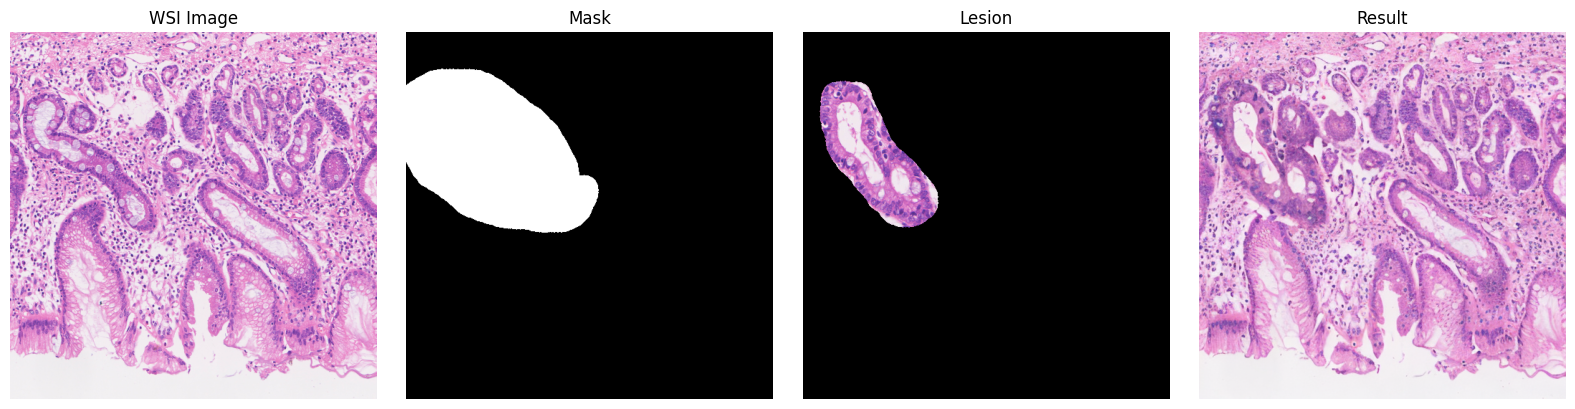

In [45]:
import matplotlib.pyplot as plt

# Create visualization
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image)
axes[0].set_title("WSI Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(condition)
axes[2].set_title("Lesion")
axes[2].axis("off")

axes[3].imshow(result)
axes[3].set_title("Result")
axes[3].axis("off")

fig.tight_layout()

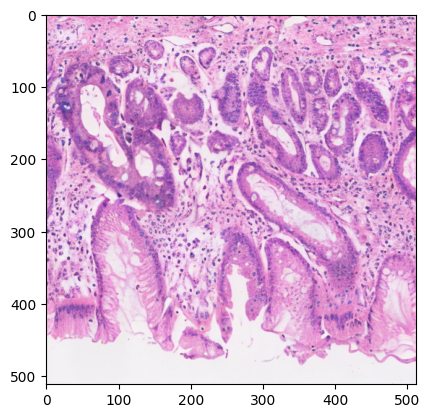

In [46]:
plt.imshow(result)
